# SETUP: `Iceland1_MARBL_2024`

This notebook prepares the first nested ROMS grid and its forcing for the Iceland1_MARBL_2024 configuration.

- **Grid import/update**: Load the child grid from MATLAB or build it with `roms_tools.Grid`.
- **Tides**: Generate TPXO tidal forcing for the child grid.
- **Initial conditions**: Interpolate from the parent (Iceland0) ROMS restart.
- **Surface forcing**: Create a year-long ERA5 forcing and UNIFIED BGC surface climatology.
- **Child of child**: Define and save the next nested grid (Iceland2) and nesting metadata.

Use this when adjusting the intermediate-resolution grid or refreshing its forcing/initial files.

# ROMS-TOOLS setup for Iceland1_MARBL_2024

First step is to set up the outer grid using ROMS-TOOLS and save the grid file.

In [1]:
from roms_tools import Grid

In [1]:
import sys; print(sys.executable)

/home/x-uheede/.conda/envs/romstools-test/bin/python


In [3]:
parent_grid='/anvil/projects/x-ees250129/x-uheede/MATLAB/setup_s2r_phys+bgc/1.Make_grid/Iceland0_grid_MAT.nc'
project='/anvil/projects/x-ees250129/x-uheede/INPUT_files/Iceland1_MARBL_2024/'
datasets='/anvil/projects/x-ees250129/Datasets/'
model_name='Iceland1'
child_name='Iceland2'
grid_path='/anvil/projects/x-ees250129/x-uheede/MATLAB/setup_r2r_phys+bgc/1.Make_grid/Iceland1_grid_MAT1.nc'

In [2]:
import os
print(os.environ["ESMFMKFILE"])

/home/x-uheede/.conda/envs/romstools-test/lib/esmf.mk


In [3]:
import xesmf

In [3]:
%%time

grid = Grid(
    nx=512,
    ny=384,
    size_x=384,
    size_y=288,
    center_lon=-22.6,
    center_lat=63.55,
    rot=0,
    mask_shapefile=datasets+"GSHHS/gshhg-shp-2.3.7/GSHHS_shp/f/GSHHS_f_L1.shp",
    topography_source={
        "name": "SRTM15",
        "path": datasets+"SRTM15/SRTM15_V2.6.nc"},
    N=60  # number of vertical layers
)

CPU times: user 7.6 s, sys: 3.18 s, total: 10.8 s
Wall time: 11.4 s


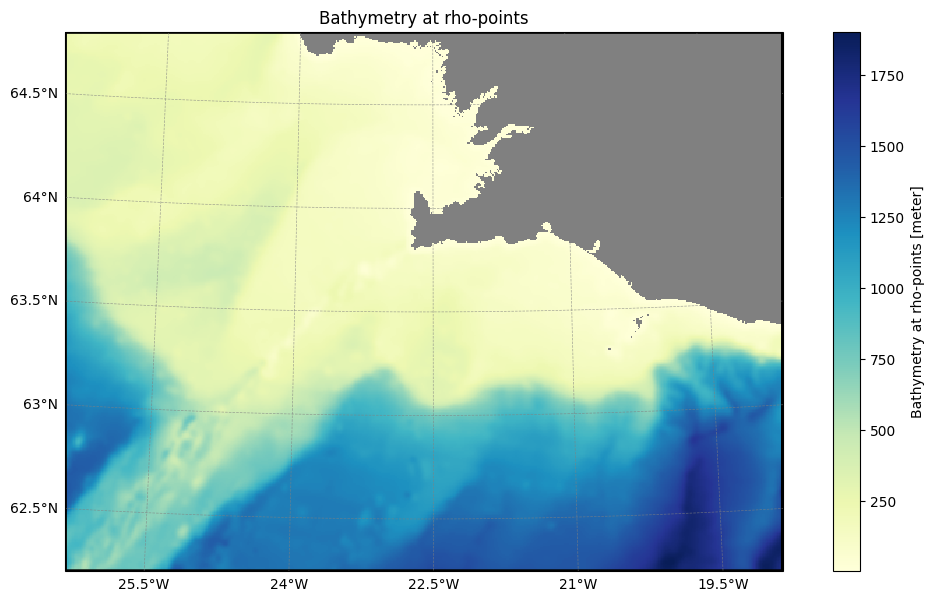

In [60]:
grid.plot()

In [61]:
import sys
sys.path.append("/anvil/projects/x-ees250129/x-uheede/fill_narrows")

import fill_narrow

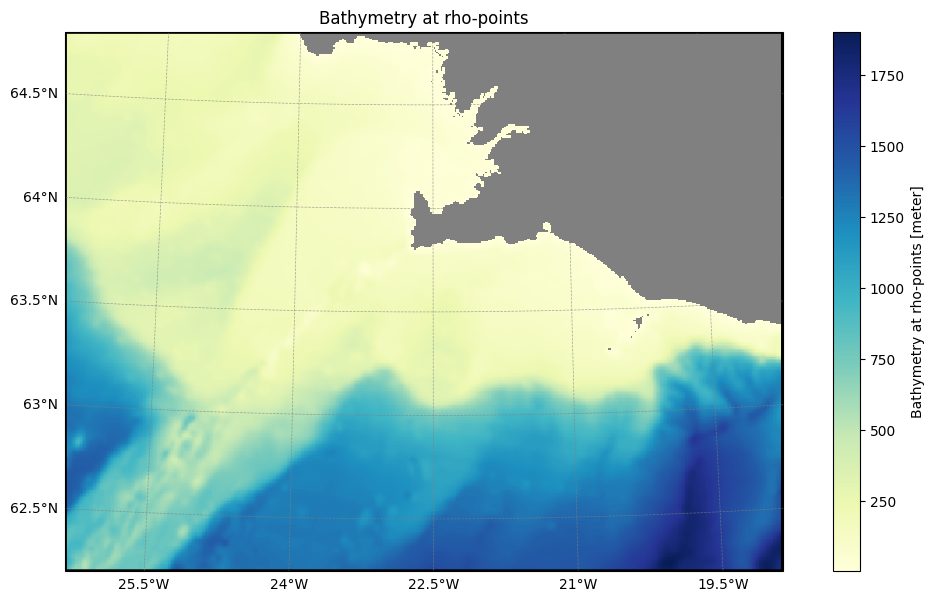

In [63]:
grid.plot()

In [4]:
# Only if using grid generated in MATLAB
grid = Grid.from_file(grid_path)
grid.update_vertical_coordinate(N=60, theta_s=5.0, theta_b=2.0, hc=300.0, verbose=False)

2026-01-26 13:10:13 - WARNING - Vertical coordinates (Cs_r, Cs_w) not found in grid file.
2026-01-26 13:10:13 - INFO - === Preparing the vertical coordinate system using N = 100, theta_s = 5.0, theta_b = 2.0, hc = 300.0 ===
2026-01-26 13:10:13 - INFO - Total time: 0.004 seconds
2026-01-26 13:10:13 - INFO - ================================================================================================


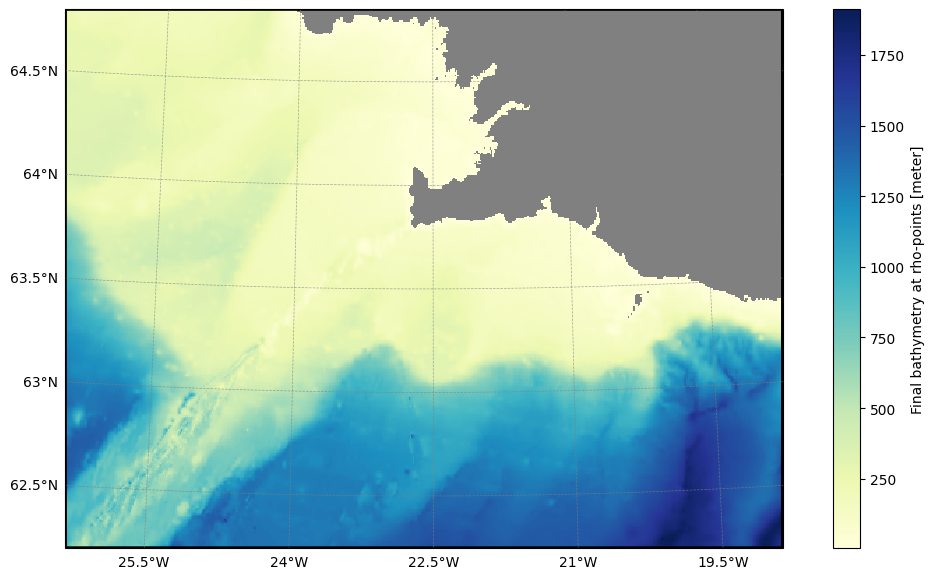

In [43]:
grid.plot()

In [5]:
filepath = project+model_name+'_grid.nc'
yaml_filepath=project+model_name+'_grid_60.yaml'

In [7]:
yaml_filepath

'/anvil/projects/x-ees250129/x-uheede/INPUT_files/Iceland1_MARBL_2024/Iceland1_grid_60.yaml'

## Step 1: Grid Creation

Builds and writes the model grid file.

In [12]:
grid.save(filepath)

2025-10-29 17:54:08 - INFO - Writing the following NetCDF files:
/anvil/projects/x-ees250129/x-uheede/INPUT_files/Iceland1_MARBL_2024/Iceland1_grid.nc


[PosixPath('/anvil/projects/x-ees250129/x-uheede/INPUT_files/Iceland1_MARBL_2024/Iceland1_grid.nc')]

In [6]:
grid.to_yaml(yaml_filepath)

In [10]:
tpxo_path = datasets+"TPXO/TPXO10.v2/"
tpxo_dict = {
    "grid": tpxo_path + "grid_tpxo10v2.nc",
    "h": tpxo_path + "h_tpxo10.v2.nc",
    "u": tpxo_path + "u_tpxo10.v2.nc",
}

Next, we set up tidal forcing:

In [11]:
from roms_tools import TidalForcing

In [6]:
from datetime import datetime

In [13]:
model_reference_date = datetime(2000, 1, 1)

In [14]:

tidal_forcing = TidalForcing(
    grid=grid,
    source={"name": "TPXO", "path": tpxo_dict},
    ntides=15,  # Number of constituents to consider <= 15. Default is 10.
    model_reference_date=model_reference_date,  # Model reference date. Default is January 1, 2000.
    use_dask=True
)

2025-10-27 13:02:37 - INFO - Applying 2D horizontal fill to the source data before regridding.
2025-10-27 13:02:37 - INFO - Applying 2D horizontal fill to the source data before regridding.
2025-10-27 13:02:38 - INFO - Applying 2D horizontal fill to the source data before regridding.
2025-10-27 13:02:38 - INFO - Applying 2D horizontal fill to the source data before regridding.


In [15]:
filepath = project+model_name+"_tides.nc"

## Step 2: Tidal Forcing Creation

Builds and writes the tidal forcing file.

In [16]:
%time tidal_forcing.save(filepath)

2025-10-27 13:02:38 - INFO - Writing the following NetCDF files:
/anvil/projects/x-ees250129/x-uheede/INPUT_files/Iceland1_MARBL_2024/Iceland1_tides.nc


[########################################] | 100% Completed | 6.04 sms
CPU times: user 2.87 s, sys: 1.11 s, total: 3.98 s
Wall time: 6.23 s


[PosixPath('/anvil/projects/x-ees250129/x-uheede/INPUT_files/Iceland1_MARBL_2024/Iceland1_tides.nc')]

## Initial conditions from parent domain

In [9]:
from roms_tools import Grid, InitialConditions

In [14]:
parent_grid = Grid.from_file('/anvil/projects/x-ees250129/x-uheede/MATLAB/setup_s2r_phys+bgc/1.Make_grid/Iceland0_grid_MAT.nc')
parent_grid.update_vertical_coordinate(N=60, theta_s=5.0, theta_b=2.0, hc=300.0, verbose=False)
restart_date = datetime(2024, 1, 20, 0, 0, 0)
restart_file = project+"Iceland0_MARBL_2024_rst.20240120000000.nc"

2026-01-22 16:17:57 - WARNING - Vertical coordinates (Cs_r, Cs_w) not found in grid file.
2026-01-22 16:17:57 - INFO - === Preparing the vertical coordinate system using N = 100, theta_s = 5.0, theta_b = 2.0, hc = 300.0 ===
2026-01-22 16:17:57 - INFO - Total time: 0.004 seconds
2026-01-22 16:17:57 - INFO - ================================================================================================


In [15]:
%%time


initial_conditions_from_roms = InitialConditions(
    grid=grid,
    ini_time=restart_date,
    source={"name": "ROMS", "grid": parent_grid, "path": restart_file},
    use_dask=True,
    bgc_source={
        "name": "ROMS",
        "grid": parent_grid,
        "path": restart_file,
    },
)


CPU times: user 4min 34s, sys: 3.74 s, total: 4min 38s
Wall time: 44.2 s


[########################################] | 100% Completed | 2.13 sms


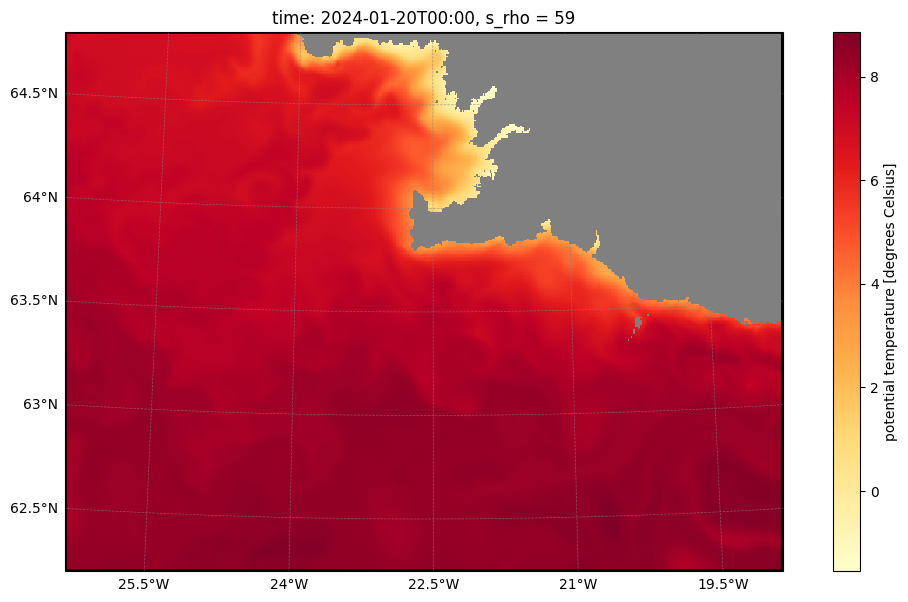

In [17]:
initial_conditions_from_roms.ds
initial_conditions_from_roms.plot("temp", s=-1)

## Step 3: Initial Conditions Creation

Builds and writes the model initial conditions file.

In [19]:
filepath = project+"Iceland0_initial_conditions_02024120.nc"
%time initial_conditions_from_roms.save(filepath)

2026-01-22 16:49:16 - INFO - Writing the following NetCDF files:
/anvil/projects/x-ees250129/x-uheede/INPUT_files/Iceland1_MARBL_2024/Iceland0_initial_conditions_02024120.nc


[########################################] | 100% Completed | 44.78 s
CPU times: user 17min 18s, sys: 15.8 s, total: 17min 34s
Wall time: 46.4 s


[PosixPath('/anvil/projects/x-ees250129/x-uheede/INPUT_files/Iceland1_MARBL_2024/Iceland0_initial_conditions_02024120.nc')]

For the surface forcing, we use ERA5 plus the unified BGC dataset

In [5]:
from roms_tools import Grid, SurfaceForcing

In [7]:
start_time = datetime(2023, 12, 1)
end_time = datetime(2024, 12, 31)

In [15]:
start_time1 = datetime(2024, 6, 1)
end_time1 = datetime(2024, 12, 1)

In [19]:
surface_forcing_kwargs = {
    "grid": grid,
    "start_time": start_time,
    "end_time": end_time,
    "type": "physics",
    "model_reference_date": datetime(2000, 1, 1), # this is the default
}

In [16]:
surface_forcing_kwargs1 = {
    "grid": grid,
    "start_time": start_time1,
    "end_time": end_time1,
    "type": "physics",
    "model_reference_date": datetime(2000, 1, 1), # this is the default
}

In [20]:
%%time

surface_forcing = SurfaceForcing(
    **surface_forcing_kwargs,
    source={"name": "ERA5"},
    use_dask=True,
)

2025-10-27 13:02:45 - INFO - No path specified for ERA5 source; defaulting to ARCO ERA5 dataset on Google Cloud.
2025-10-27 13:04:30 - INFO - Data will be interpolated onto the grid coarsened by factor 2. Remember to set `interp_frc = 1` in your `bulk_frc.opt` ROMS option file.
2025-10-27 13:04:30 - INFO - Applying 2D horizontal fill to the source data before regridding.
2025-10-27 13:04:33 - INFO - Applying 2D horizontal fill to the source data before regridding.


CPU times: user 2min 49s, sys: 7.95 s, total: 2min 57s
Wall time: 3min


In [17]:
%%time

surface_forcing1 = SurfaceForcing(
    **surface_forcing_kwargs1,
    source={"name": "ERA5"},
    use_dask=True,
)

2025-10-29 17:55:31 - INFO - No path specified for ERA5 source; defaulting to ARCO ERA5 dataset on Google Cloud.
2025-10-29 17:57:16 - INFO - Data will be interpolated onto the grid coarsened by factor 2. Remember to set `interp_frc = 1` in your `bulk_frc.opt` ROMS option file.
2025-10-29 17:57:17 - INFO - Applying 2D horizontal fill to the source data before regridding.
2025-10-29 17:57:20 - INFO - Applying 2D horizontal fill to the source data before regridding.


CPU times: user 2min 34s, sys: 12.6 s, total: 2min 46s
Wall time: 2min 50s


[########################################] | 100% Completed | 101.99 ms


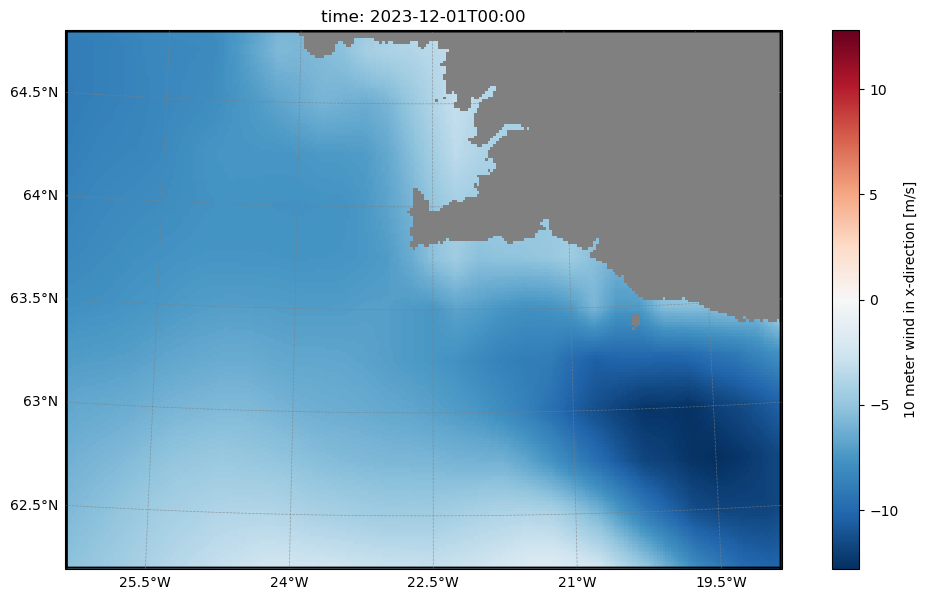

In [21]:
surface_forcing.plot("uwnd", time=0)

In [8]:
#cesm_bgc_path = "/global/cfs/projectdirs/m4746/Datasets/CESM_REGRIDDED/CESM-surface_lowres_regridded.nc"
unified_bgc_path = datasets+"UNIFIED/BGCdataset.nc"

In [10]:
%%time

unified_bgc_surface_forcing = SurfaceForcing(
    grid=grid,
    start_time=start_time,
    end_time=end_time,
    source={"name": "UNIFIED", "path": unified_bgc_path, "climatology": True},
    type="bgc",
    use_dask=True,
)

2026-01-26 13:11:01 - WARNING - Optional variables missing (but not critical): ['pco2_air_alt']
2026-01-26 13:11:01 - INFO - Data will be interpolated onto the grid coarsened by factor 2. Remember to set `interp_frc = 1` in your `bgc.opt` ROMS option file.


CPU times: user 138 ms, sys: 12 ms, total: 150 ms
Wall time: 235 ms


In [18]:
filepath = project+model_name+"_surface_forcing2024.nc"

## Step 4: Surface Forcing Creation

Builds and writes the physical surface forcing file.

In [25]:
%time surface_forcing.save(filepath, group=True)

2025-10-27 13:05:53 - INFO - Writing the following NetCDF files:
/anvil/projects/x-ees250129/x-uheede/INPUT_files/Iceland1_MARBL_2024/Iceland1_surface_forcing2024_202312.nc
/anvil/projects/x-ees250129/x-uheede/INPUT_files/Iceland1_MARBL_2024/Iceland1_surface_forcing2024_202401.nc
/anvil/projects/x-ees250129/x-uheede/INPUT_files/Iceland1_MARBL_2024/Iceland1_surface_forcing2024_202402.nc
/anvil/projects/x-ees250129/x-uheede/INPUT_files/Iceland1_MARBL_2024/Iceland1_surface_forcing2024_202403.nc
/anvil/projects/x-ees250129/x-uheede/INPUT_files/Iceland1_MARBL_2024/Iceland1_surface_forcing2024_202404.nc
/anvil/projects/x-ees250129/x-uheede/INPUT_files/Iceland1_MARBL_2024/Iceland1_surface_forcing2024_202405.nc
/anvil/projects/x-ees250129/x-uheede/INPUT_files/Iceland1_MARBL_2024/Iceland1_surface_forcing2024_202406.nc


[########################################] | 100% Completed | 77.22 s
[########################################] | 100% Completed | 79.04 s
[########################################] | 100% Completed | 74.84 s
[########################################] | 100% Completed | 79.05 s
[########################################] | 100% Completed | 77.91 s
[########################################] | 100% Completed | 80.71 s
[########################################] | 100% Completed | 77.10 s
CPU times: user 15min 33s, sys: 2min 11s, total: 17min 44s
Wall time: 10min 47s


[PosixPath('/anvil/projects/x-ees250129/x-uheede/INPUT_files/Iceland1_MARBL_2024/Iceland1_surface_forcing2024_202312.nc'),
 PosixPath('/anvil/projects/x-ees250129/x-uheede/INPUT_files/Iceland1_MARBL_2024/Iceland1_surface_forcing2024_202401.nc'),
 PosixPath('/anvil/projects/x-ees250129/x-uheede/INPUT_files/Iceland1_MARBL_2024/Iceland1_surface_forcing2024_202402.nc'),
 PosixPath('/anvil/projects/x-ees250129/x-uheede/INPUT_files/Iceland1_MARBL_2024/Iceland1_surface_forcing2024_202403.nc'),
 PosixPath('/anvil/projects/x-ees250129/x-uheede/INPUT_files/Iceland1_MARBL_2024/Iceland1_surface_forcing2024_202404.nc'),
 PosixPath('/anvil/projects/x-ees250129/x-uheede/INPUT_files/Iceland1_MARBL_2024/Iceland1_surface_forcing2024_202405.nc'),
 PosixPath('/anvil/projects/x-ees250129/x-uheede/INPUT_files/Iceland1_MARBL_2024/Iceland1_surface_forcing2024_202406.nc')]

## Step 5: Generated File Output

Writes a generated setup file to disk.

In [19]:
%time surface_forcing1.save(filepath, group=True)

2025-10-29 17:58:23 - INFO - Writing the following NetCDF files:
/anvil/projects/x-ees250129/x-uheede/INPUT_files/Iceland1_MARBL_2024/Iceland1_surface_forcing2024_202406.nc
/anvil/projects/x-ees250129/x-uheede/INPUT_files/Iceland1_MARBL_2024/Iceland1_surface_forcing2024_202407.nc
/anvil/projects/x-ees250129/x-uheede/INPUT_files/Iceland1_MARBL_2024/Iceland1_surface_forcing2024_202408.nc
/anvil/projects/x-ees250129/x-uheede/INPUT_files/Iceland1_MARBL_2024/Iceland1_surface_forcing2024_202409.nc
/anvil/projects/x-ees250129/x-uheede/INPUT_files/Iceland1_MARBL_2024/Iceland1_surface_forcing2024_202410.nc
/anvil/projects/x-ees250129/x-uheede/INPUT_files/Iceland1_MARBL_2024/Iceland1_surface_forcing2024_202411.nc
/anvil/projects/x-ees250129/x-uheede/INPUT_files/Iceland1_MARBL_2024/Iceland1_surface_forcing2024_202412.nc


[########################################] | 100% Completed | 73.88 s
[########################################] | 100% Completed | 76.59 s
[########################################] | 100% Completed | 77.23 s
[########################################] | 100% Completed | 76.66 s
[########################################] | 100% Completed | 75.70 s
[########################################] | 100% Completed | 74.32 s
[########################################] | 100% Completed | 409.54 ms
CPU times: user 12min 45s, sys: 2min, total: 14min 45s
Wall time: 9min 6s


[PosixPath('/anvil/projects/x-ees250129/x-uheede/INPUT_files/Iceland1_MARBL_2024/Iceland1_surface_forcing2024_202406.nc'),
 PosixPath('/anvil/projects/x-ees250129/x-uheede/INPUT_files/Iceland1_MARBL_2024/Iceland1_surface_forcing2024_202407.nc'),
 PosixPath('/anvil/projects/x-ees250129/x-uheede/INPUT_files/Iceland1_MARBL_2024/Iceland1_surface_forcing2024_202408.nc'),
 PosixPath('/anvil/projects/x-ees250129/x-uheede/INPUT_files/Iceland1_MARBL_2024/Iceland1_surface_forcing2024_202409.nc'),
 PosixPath('/anvil/projects/x-ees250129/x-uheede/INPUT_files/Iceland1_MARBL_2024/Iceland1_surface_forcing2024_202410.nc'),
 PosixPath('/anvil/projects/x-ees250129/x-uheede/INPUT_files/Iceland1_MARBL_2024/Iceland1_surface_forcing2024_202411.nc'),
 PosixPath('/anvil/projects/x-ees250129/x-uheede/INPUT_files/Iceland1_MARBL_2024/Iceland1_surface_forcing2024_202412.nc')]

In [11]:
filepath = project+model_name+"_bgc_surface_forcing.nc"

## Step 6: BGC Surface Forcing Creation

Builds and writes the biogeochemical surface forcing file.

In [12]:
%time unified_bgc_surface_forcing.save(filepath)

2026-01-26 13:11:11 - INFO - Writing the following NetCDF files:
/anvil/projects/x-ees250129/x-uheede/INPUT_files/Iceland1_MARBL_2024/Iceland1_bgc_surface_forcing_clim.nc


[########################################] | 100% Completed | 102.28 ms
CPU times: user 181 ms, sys: 73.4 ms, total: 254 ms
Wall time: 211 ms


[PosixPath('/anvil/projects/x-ees250129/x-uheede/INPUT_files/Iceland1_MARBL_2024/Iceland1_bgc_surface_forcing_clim.nc')]

Next we generate the initial file

In [4]:
from roms_tools import Grid, ChildGrid

In [5]:
child_grid_parameters = {
    "nx": 512,
    "ny": 512,
    "size_x": 102.4,
    "size_y": 102.4,
    "center_lon": -22.3,
    "center_lat": 64.39,
    "rot": 0,
    "mask_shapefile": datasets+"GSHHS/gshhg-shp-2.3.7/GSHHS_shp/f/GSHHS_f_L1.shp",
    "topography_source": {
        "name": "EMOD",
        "path": datasets+"EMODnet_C2.nc"},
    "N":60  # number of vertical layers
}

In [6]:
child_grid = ChildGrid(
    **child_grid_parameters,
    parent_grid=grid,
    boundaries={
        "south": True,
        "east": False,
        "north": False,
        "west": True,
    },  # this is the default
    metadata={"prefix": "child", "period": 1800.0}  # this is the default
)

2026-01-22 18:33:18 - INFO - Using boundary configuration: {'south': True, 'east': False, 'north': False, 'west': True}


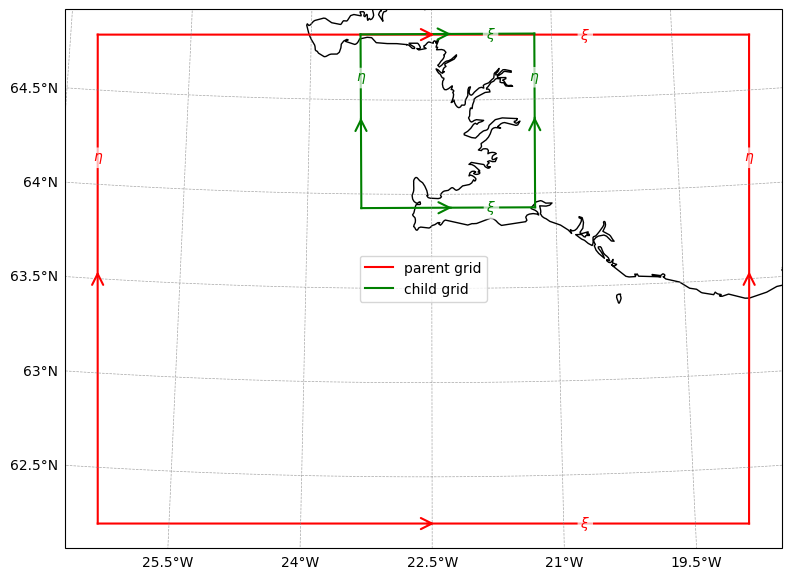

In [7]:
child_grid.plot_nesting(with_dim_names=True)

## Step 7: Child Grid Creation

Builds and writes the child grid file.

In [ ]:
filepath = project+child_name+"_grid.nc"
child_grid.save(filepath=filepath)

In [8]:
filepath_nesting = project+child_name+"_edata.nc"

In [9]:
child_grid.save_nesting(filepath=filepath_nesting)

2026-01-22 18:34:05 - INFO - Writing the following NetCDF files:
/anvil/projects/x-ees250129/x-uheede/INPUT_files/Iceland1_MARBL_2024/Iceland2_edata.nc


[PosixPath('/anvil/projects/x-ees250129/x-uheede/INPUT_files/Iceland1_MARBL_2024/Iceland2_edata.nc')]